In [8]:
!unzip -q "/content/drive/MyDrive/Ai Palmistry project/archive.zip" -d "/content/dataset"

replace /content/dataset/HandInfo.csv? [y]es, [n]o, [A]ll, [N]one, [r]ename: 

In [9]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from PIL import Image

In [10]:
df = pd.read_csv("/content/dataset/HandInfo.csv")

In [11]:
df.head()

,id,age,gender,skinColor,accessories,nailPolish,aspectOfHand,imageName,irregularities
0,0,27,male,fair,0,0,dorsal right,Hand_0000002.jpg,0
1,0,27,male,fair,0,0,dorsal right,Hand_0000003.jpg,0
2,0,27,male,fair,0,0,dorsal right,Hand_0000004.jpg,0
3,0,27,male,fair,0,0,dorsal right,Hand_0000005.jpg,0
4,0,27,male,fair,0,0,dorsal right,Hand_0000006.jpg,0


In [12]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 11076 entries, 0 to 11075
Data columns (total 9 columns):
 #   Column          Non-Null Count  Dtype 
---  ------          --------------  ----- 
 0   id              11076 non-null  int64 
 1   age             11076 non-null  int64 
 2   gender          11076 non-null  object
 3   skinColor       11076 non-null  object
 4   accessories     11076 non-null  int64 
 5   nailPolish      11076 non-null  int64 
 6   aspectOfHand    11076 non-null  object
 7   imageName       11076 non-null  object
 8   irregularities  11076 non-null  int64 
dtypes: int64(5), object(4)
memory usage: 778.9+ KB


Total records: 11,076 hand images
Total features: 9 columns
Missing values: None (all columns have 11,076 non-null values)
Numerical columns: 5 (id, age, accessories, nailPolish, irregularities)
Categorical columns: 4 (gender, skinColor, aspectOfHand, imageName)

The dataset contains 11,076 hand images with 9 attributes. No missing values were found, making it suitable for further analysis without preprocessing for null values.

In [13]:
df.describe()

,id,age,accessories,nailPolish,irregularities
count,1.107600e+04,11076.000000,11076.000000,11076.000000,11076.000000
mean,2.031043e+05,22.494583,0.289906,0.096334,0.014807
std,1.086731e+06,6.918974,0.453739,0.295063,0.120784
min,0.000000e+00,18.000000,0.000000,0.000000,0.000000
25%,5.760000e+02,21.000000,0.000000,0.000000,0.000000
50%,1.050000e+03,21.000000,0.000000,0.000000,0.000000
75%,1.539250e+03,22.000000,1.000000,0.000000,0.000000
max,9.000000e+06,75.000000,1.000000,1.000000,1.000000


## 2. Statistical Summary

- Total samples: 11,076
- Age ranges from 18–75 years.
- Average age is 22.5 years.
- Binary attributes (Accessories, Nail Polish, Irregularities) contain values 0 and 1.
- The `id` column is only an identifier and does not contribute to prediction.

In [14]:
df.isnull().sum()

,0
id,0
age,0
gender,0
skinColor,0
accessories,0
nailPolish,0
aspectOfHand,0
imageName,0
irregularities,0


Missing Value Analysis: No missing values were found in any of the 9 features. Therefore, no missing value imputation was required.

In [15]:
df.duplicated().sum()

np.int64(0)

No duplicate records were found, indicating that each image entry in the dataset is unique.

In [16]:
df["aspectOfHand"].value_counts()

,count
aspectOfHand,
dorsal right,2892
palmar right,2813
dorsal left,2788
palmar left,2583


The dataset is fairly balanced.
There are 4 classes:

Dorsal Right: 2892

Palmar Right: 2813

Dorsal Left: 2788

Palmar Left: 2583








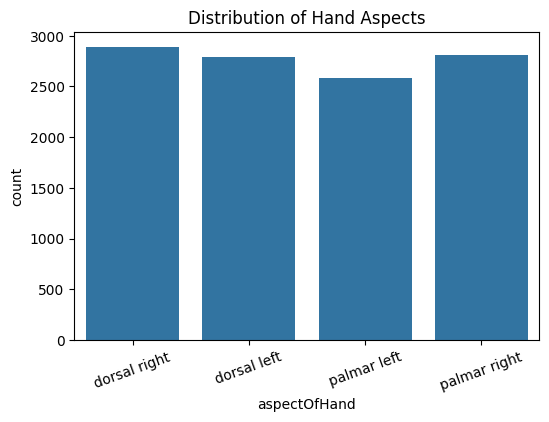

In [17]:
plt.figure(figsize=(6,4))
sns.countplot(data=df, x="aspectOfHand")
plt.title("Distribution of Hand Aspects")
plt.xticks(rotation=20)
plt.show()

The distribution of hand aspects is nearly balanced across all four classes. The dataset contains dorsal and palmar images for both left and right hands, with no severe class imbalance. Since our project focuses on palm line analysis, only the palmar images (left and right) will be used in the later stages."

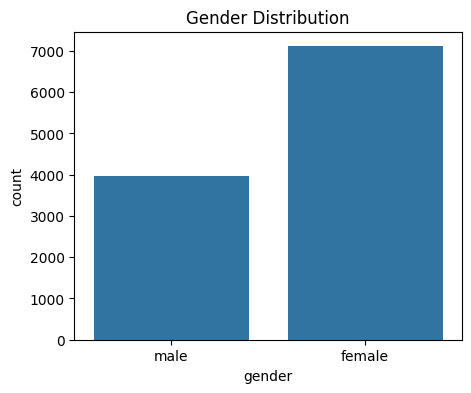

In [18]:
plt.figure(figsize=(5,4))
sns.countplot(data=df, x="gender")
plt.title("Gender Distribution")
plt.show()

The dataset contains more female hand images than male hand images. Although there is some imbalance, both genders are well represented, which makes the dataset suitable for analysis.

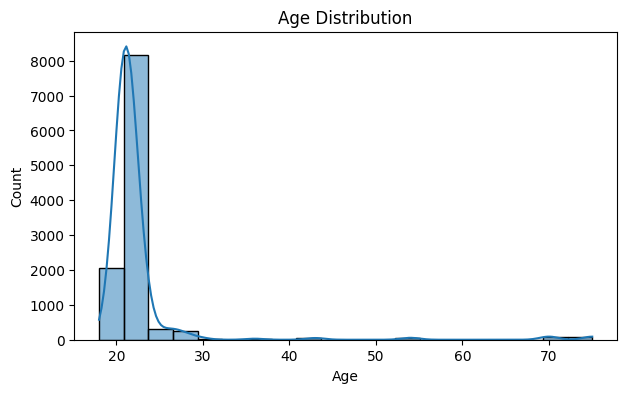

In [19]:
plt.figure(figsize=(7,4))
sns.histplot(df["age"], bins=20, kde=True)
plt.title("Age Distribution")
plt.xlabel("Age")
plt.ylabel("Count")
plt.show()

The age distribution is right-skewed. Most participants are between 18 and 25 years, with a peak around 21–22 years. Only a small number of samples belong to older age groups (30–75 years).

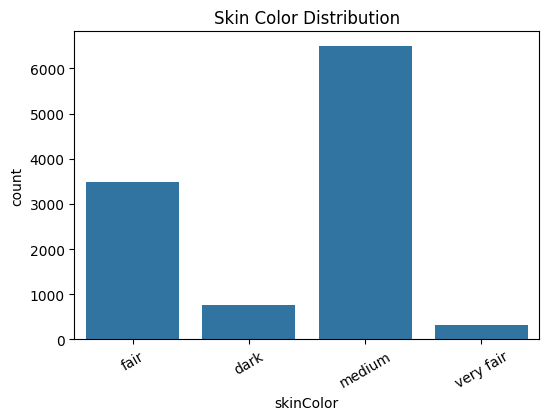

In [20]:
plt.figure(figsize=(6,4))
sns.countplot(data=df, x="skinColor")
plt.title("Skin Color Distribution")
plt.xticks(rotation=30)
plt.show()

The dataset contains four skin tone categories. The medium skin tone has the highest number of samples, followed by fair. Dark and very fair skin tones are less represented. This indicates a moderate imbalance in skin tone distribution.

In [21]:
binary_cols = ["accessories", "nailPolish", "irregularities"]

for col in binary_cols:
    print("\n", col)
    print(df[col].value_counts())


 accessories
accessories
0    7865
1    3211
Name: count, dtype: int64

 nailPolish
nailPolish
0    10009
1     1067
Name: count, dtype: int64

 irregularities
irregularities
0    10912
1      164
Name: count, dtype: int64


### Binary Feature Analysis

- Around 29% of hand images contain accessories.
- Only about 10% of images have nail polish.
- Hand irregularities are very rare (about 1.5%), indicating that most hands in the dataset are healthy and unobstructed.

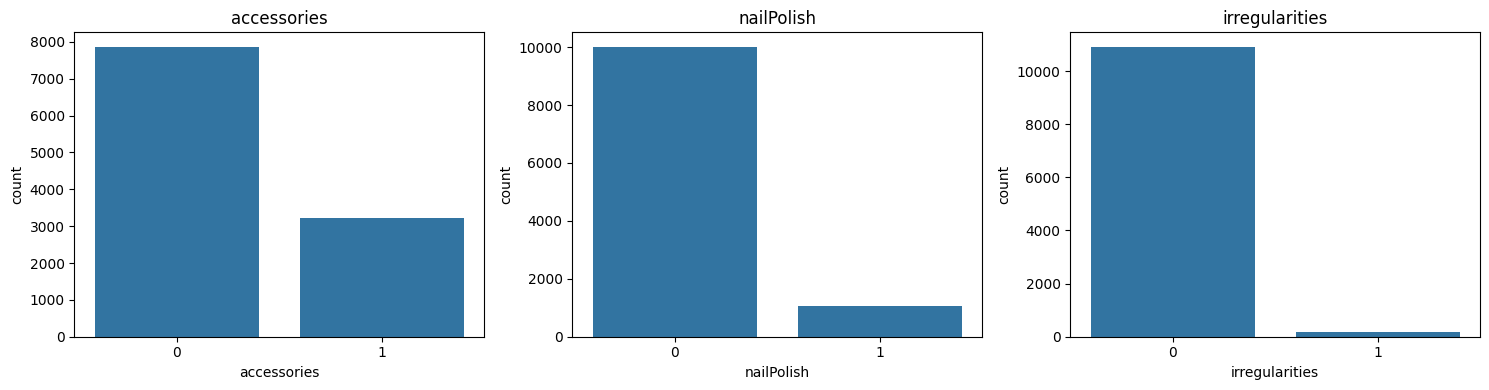

In [22]:
fig, axes = plt.subplots(1, 3, figsize=(15,4))

binary_cols = ["accessories", "nailPolish", "irregularities"]

for i, col in enumerate(binary_cols):
    sns.countplot(data=df, x=col, ax=axes[i])
    axes[i].set_title(col)

plt.tight_layout()
plt.show()

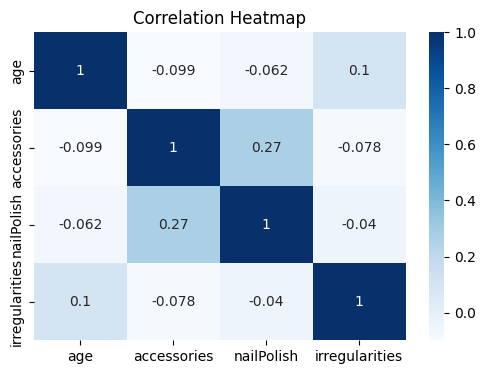

In [23]:
plt.figure(figsize=(6,4))

sns.heatmap(
    df[["age","accessories","nailPolish","irregularities"]].corr(),
    annot=True,
    cmap="Blues"
)

plt.title("Correlation Heatmap")
plt.show()

In [25]:
import os
from PIL import Image

sample_image = os.path.join("/content/dataset/Hands/Hands", df.iloc[0]["imageName"])

img = Image.open(sample_image)

print("Image Size:", img.size)
print("Image Mode:", img.mode)

Image Size: (1600, 1200)
Image Mode: RGB


The dataset consists of high-resolution RGB images, which are suitable for computer vision tasks such as palm detection and palm line extraction. Before model training, the images will likely be resized to a smaller resolution (e.g., 224×224) to reduce computational cost.

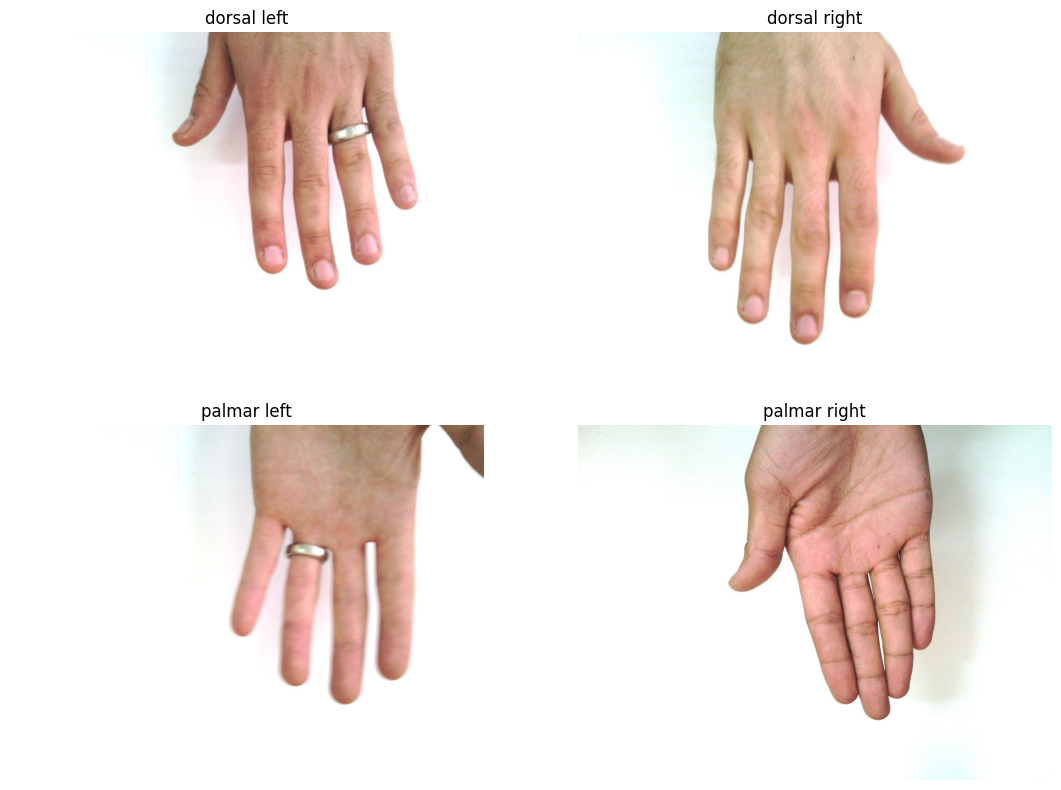

In [29]:
categories = ["dorsal left", "dorsal right", "palmar left", "palmar right"]

plt.figure(figsize=(12, 8))

for i, category in enumerate(categories):
    image_name = df[df["aspectOfHand"] == category].iloc[0]["imageName"]
    img = Image.open(f"/content/dataset/Hands/Hands/{image_name}")

    plt.subplot(2, 2, i+1)
    plt.imshow(img)
    plt.title(category)
    plt.axis("off")

plt.tight_layout()
plt.show()

The dataset contains four categories of hand images:

Dorsal Left
Dorsal Right
Palmar Left
Palmar Right

Since the objective of this project is palm line detection and palmistry analysis, only the palmar left and palmar right images will be used in the later stages.

In [30]:
palmar_df = df[df["aspectOfHand"].str.contains("palmar")]

print("Number of palmar images:", len(palmar_df))
palmar_df.head()

Number of palmar images: 5396


,id,age,gender,skinColor,accessories,nailPolish,aspectOfHand,imageName,irregularities
30,0,27,male,fair,1,0,palmar left,Hand_0000038.jpg,0
31,0,27,male,fair,1,0,palmar left,Hand_0000039.jpg,0
32,0,27,male,fair,1,0,palmar left,Hand_0000040.jpg,0
33,0,27,male,fair,1,0,palmar left,Hand_0000041.jpg,0
34,0,27,male,fair,1,0,palmar left,Hand_0000042.jpg,0


## Palmar Image Selection

The original dataset contains both dorsal (back of hand) and palmar (palm) images.

Since the objective of this project is palm line detection and palmistry analysis, only the **palmar** images are selected.

- Total images in dataset: **11,076**
- Total palmar images: **5,396**

The remaining dorsal images are excluded from further processing.

In [31]:
palmar_df["aspectOfHand"].value_counts()

,count
aspectOfHand,
palmar right,2813
palmar left,2583


### Palmar Image Distribution

The filtered dataset contains **5,396** palm images.

- Palmar Right: **2,813**
- Palmar Left: **2,583**

The two classes are nearly balanced, making the dataset suitable for training a palm analysis model.

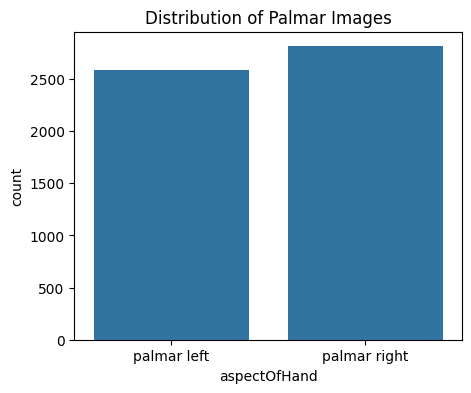

In [32]:
plt.figure(figsize=(5,4))
sns.countplot(data=palmar_df, x="aspectOfHand")
plt.title("Distribution of Palmar Images")
plt.show()

# Final EDA Summary

### Key Findings

- The dataset contains **11,076** hand images with **9 metadata attributes**.
- No missing or duplicate records were found.
- Images are categorized into four classes: dorsal left, dorsal right, palmar left, and palmar right.
- The dataset contains **5,396** palmar images, which are relevant for the palmistry project.
- Images have a resolution of **1600 × 1200** pixels and are in **RGB** format.
- The dataset is well-balanced across hand aspects and provides sufficient data for palm detection and palm line analysis.

## Relevance to the Project

This dataset contains both dorsal and palmar hand images. Since our objective is palmistry analysis, only the palmar images will be used for further preprocessing, palm region extraction, and palm line detection. The metadata was explored to understand the dataset quality and identify the features relevant to our project.